# Persiapan

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as npy # linear algebra
import pandas as pds # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator as ImgDataGen

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


2026-05-20 01:17:29.829786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779239850.038146      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779239850.104238      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779239850.619178      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779239850.619219      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779239850.619223      57 computation_placer.cc:177] computation placer alr

In [2]:
# Specify important directories
import os, sys, time, warnings, sklearn
ROOT='/kaggle/input'
# ROOT='data'
TEST_PATH= "/kaggle/input/datasets/ananthu017/emotion-detection-fer/test"
TRAIN_PATH='/kaggle/input/datasets/ananthu017/emotion-detection-fer/train'

train_angry_img_path=TRAIN_PATH +'/angry'

OVERSAMPLED_TRAIN_PATH='fed_oversampled_train'
MODEL_PATH='models'
IMAGE_PATH='images'

# EDA

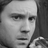

In [3]:
# Load a sample image 
# using open() to open images
image_data = Image.open(train_angry_img_path+'/im0.png')
image_data

Image shape: (48, 48)
Image data array: [[ 70  80  82 ...  52  43  41]
 [ 65  61  58 ...  56  52  44]
 [ 50  43  54 ...  49  56  47]
 ...
 [ 91  65  42 ...  72  56  43]
 [ 77  82  79 ... 105  70  46]
 [ 77  72  84 ... 106 109  82]]
Image array shape: (48, 48)


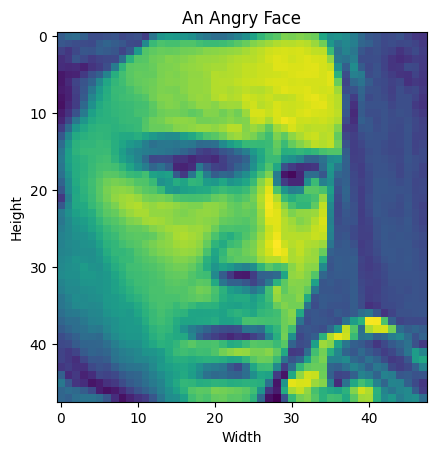

In [4]:
# Get the shape of the image
image=plt.imread(train_angry_img_path+'/im0.png')
print(f'Image shape: {image.shape}')

# Convert image data (like jpeg) to numpy using asarray()
image_array = npy.asarray(image_data)
print(f'Image data array: {image_array}')

# Get the shape of the image array
print(f'Image array shape: {image_array.shape}')

# Printing the image 
plt.imshow(image_array)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('An Angry Face')
plt.show()

In [5]:
# Get the list of folders in the directory as classes
classes=os.listdir(TRAIN_PATH+'/')
classes

['fearful', 'disgusted', 'angry', 'neutral', 'sad', 'surprised', 'happy']

In [6]:
# Get dictionary list of image count per class
def class_sample(type):
    if type.lower() == 'test' or type.lower() == 'train':
        path=''
        if type.lower() == 'train':    
            path= TRAIN_PATH
        else:
            path= TEST_PATH
        
        filepath=path+'/'
        class_count = []
        class_dict ={}
        for folder in os.listdir(filepath) :
              class_count.append(len(os.listdir(filepath+folder)))
              class_dict[folder]=len(os.listdir(filepath+folder))
        class_total = sum(class_count)
        return class_total, class_count, class_dict
    else:
        raise ValueError('Invalid type. Must be "test" or "train".')


def test_train_distribution():
      print("---- Train Set ----")
      avg_train=class_sample('train')[0]/len(class_sample('train')[1])
      print(f'Train class distribution:\n{class_sample("train")[2]}')
      print("Average train class: ",round(avg_train))    
      print('Total train: ', class_sample('train')[0])

      print("\n---- Test Set ----")
      avg_test=class_sample('test')[0]/len(class_sample('test')[1])
      print(f'Test class distribution:\n{class_sample("test")[2]}')
      print("Average test class: ",round(avg_test)) 
      print('Total test: ', class_sample('test')[0])


test_train_distribution()

---- Train Set ----
Train class distribution:
{'fearful': 4097, 'disgusted': 436, 'angry': 3995, 'neutral': 4965, 'sad': 4830, 'surprised': 3171, 'happy': 7215}
Average train class:  4101
Total train:  28709

---- Test Set ----
Test class distribution:
{'fearful': 1024, 'disgusted': 111, 'angry': 958, 'neutral': 1233, 'sad': 1247, 'surprised': 831, 'happy': 1774}
Average test class:  1025
Total test:  7178


# Data Preprocessing

## Oversampling

In [8]:
# Oversampling Technique
import os
from PIL import Image

# Define the paths to the original and oversampled dataset
train_dir = TRAIN_PATH
oversampled_dir = OVERSAMPLED_TRAIN_PATH

target_length = 7215 # highest count in a class
# target_length = 4101 Average

if not os.path.exists(oversampled_dir):
    os.mkdir(oversampled_dir)

for subfolder in os.listdir(train_dir):
    subfolder_path = os.path.join(train_dir, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len(os.listdir(subfolder_path))
        num_duplicates = target_length // num_images
        remainder = target_length % num_images

        for i in range(num_duplicates):
            for image_file in os.listdir(subfolder_path):
                image_path = os.path.join(subfolder_path, image_file)
                image = Image.open(image_path)
                new_image_file = f"{i}_{image_file}"
                new_image_path = os.path.join(oversampled_dir, subfolder, new_image_file)
                if not os.path.exists(os.path.join(oversampled_dir, subfolder)):
                    os.mkdir(os.path.join(oversampled_dir, subfolder))
                image.save(new_image_path)

        if remainder != 0:
            for image_file in os.listdir(subfolder_path)[:remainder]:
                image_path = os.path.join(subfolder_path, image_file)
                image = Image.open(image_path)
                new_image_file = f"{num_duplicates}_{image_file}"
                new_image_path = os.path.join(oversampled_dir, subfolder, new_image_file)
                if not os.path.exists(os.path.join(oversampled_dir, subfolder)):
                    os.mkdir(os.path.join(oversampled_dir, subfolder))
                image.save(new_image_path)

In [9]:
# Get dictionary list of image count per class
def over_class_sample():
        filepath=OVERSAMPLED_TRAIN_PATH+'/'
        class_count = []
        class_dict ={}
        for folder in os.listdir(filepath) :
              class_count.append(len(os.listdir(filepath+folder)))
              class_dict[folder]=len(os.listdir(filepath+folder))
        class_total = sum(class_count)
        return class_total, class_count, class_dict

In [10]:
def test_train_distribution():
      print("\n---- Oversampled Train Set ----")
      avg_train=over_class_sample()[0]/len(over_class_sample()[1])
      print(f'Train class distribution:\n{over_class_sample()[2]}')
      print("Average train class: ",round(avg_train))    
      print('Total train: ', over_class_sample()[0])



test_train_distribution()


---- Oversampled Train Set ----
Train class distribution:
{'angry': 7215, 'neutral': 7215, 'disgusted': 7215, 'surprised': 7215, 'sad': 7215, 'fearful': 7215, 'happy': 7215}
Average train class:  7215
Total train:  50505


## Data Augmentation

In [11]:
target_size=(48, 48)
# target_size=(224, 224)
batch_size=32

## Train Image Data Generator instance. 
# We will not apply any transformon specific orientations or features and no initial rescale to the image
# We'll only split the image data into train and validation set
trainValidation_data_generator = ImgDataGen(
                                    rescale=1./255,  # Gunakan 255, bukan 225
                                    rotation_range=10,
                                    zoom_range=0.2,
                                    width_shift_range=0.1,
                                    height_shift_range=0.1,
                                    shear_range=0.2,
                                    horizontal_flip=True,
                                    fill_mode='nearest',
                                    validation_split=0.2
)


# Test Image Data Generator instance for Test data
test_data_generator = ImgDataGen(
                                rescale = 1./255,
                                )


# Data Generator

In [12]:
pip install -U albumentations

Note: you may need to restart the kernel to use updated packages.


In [14]:
import albumentations as A
import numpy as np
import tensorflow as tf

img_height = 48
img_width = 48

# Pipeline untuk Data Training (Dengan Augmentasi Agresif)
train_transform = A.Compose([
    A.Resize(img_height, img_width),
    A.HorizontalFlip(p=0.5), # Membalik wajah kiri-kanan
    A.RandomBrightnessContrast(p=0.2), # Mengatasi masalah pencahayaan berbeda
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5), # Menajamkan kontur wajah
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    
    # CoarseDropout: Menghapus kotak acak pada wajah (misal menutupi sebelah mata/mulut)
    A.CoarseDropout(max_holes=1, max_height=12, max_width=12, min_holes=1, 
                    min_height=8, min_width=8, fill_value=0, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) # Normalisasi standar
])

# Pipeline untuk Validation & Test Data (Tanpa Augmentasi, Hanya Rescaling & Normalisasi)
val_transform = A.Compose([
    A.Resize(img_height, img_width),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_57/3913862349.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=12, max_width=12, min_holes=1,


In [15]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

class AlbumentationsDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=32, shuffle=True, transform=None, 
                 classes=None, validation_split=0.2, subset='training', random_state=42):
        self.directory = directory
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.transform = transform
        self.classes = classes if classes else sorted(os.listdir(directory))
        self.class_indices = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # 1. Kumpulkan semua data mentah terlebih dahulu
        all_image_paths = []
        all_labels = []
        for class_name in self.classes:
            class_path = os.path.join(directory, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    all_image_paths.append(os.path.join(class_path, img_name))
                    all_labels.append(self.class_indices[class_name])
                    
        # 2. Lakukan splitting menggunakan train_test_split (Stratified agar seimbang tiap kelas)
        train_paths, val_paths, train_lbls, val_lbls = train_test_split(
            all_image_paths, all_labels, 
            test_size=validation_split, 
            stratify=all_labels, # Menjaga rasio distribusi kelas tetap sama
            random_state=random_state
        )
        
        # 3. Tentukan data mana yang diambil berdasarkan subset
        if subset == 'training':
            self.image_paths = train_paths
            self.labels = train_lbls
        elif subset == 'validation':
            self.image_paths = val_paths
            self.labels = val_lbls
            self.shuffle = False # Amankan data val agar tidak di-shuffle otomatis
        else:
            raise ValueError("Subset harus berupa 'training' atau 'validation'")
                    
        self.indices = np.arange(len(self.image_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        X = []
        y = []
        
        for idx in batch_indices:
            img_path = self.image_paths[idx]
            label = self.labels[idx]
            
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']
            
            X.append(image)
            y.append(label)
            
        return np.array(X), to_categorical(np.array(y), num_classes=len(self.classes))

In [16]:
# Jalur folder induk data training kamu sebelum di-split
DATA_DIR = OVERSAMPLED_TRAIN_PATH 

# Generator untuk Subset Training (Mendapat Augmentasi Kuat)
train_generator = AlbumentationsDataGenerator(
    directory=DATA_DIR,
    batch_size=32,
    validation_split=0.2,   # 80% untuk Train
    subset='training',
    shuffle=True,
    transform=train_transform, # Menggunakan Albumentations augmentasi wajah
    classes=classes
)

# Generator untuk Subset Validation (Hanya Rescaling/Normalisasi bersih)
validation_generator = AlbumentationsDataGenerator(
    directory=DATA_DIR,
    batch_size=32,
    validation_split=0.2,   # 20% untuk Val
    subset='validation',
    transform=val_transform,   # Menggunakan transform bersih tanpa rusakin gambar
    classes=classes
)

test_generator = AlbumentationsDataGenerator(
    directory=TEST_PATH,          # Folder data test kamu
    batch_size=32,
    shuffle=False,                # WAJIB False untuk pengujian/evaluasi
    transform=val_transform,       # Gunakan val_transform (Tanpa augmentasi rusak)
    classes=classes
)

In [18]:
test_samples=class_sample('test')[0]
test_batch_size=batch_size
test_steps=int(test_samples/test_batch_size)

In [19]:
# From the generator we can get information we will need later
# classes=  # os.listdir(TRAIN_PATH+'/')
class_dictionary = train_generator.class_indices
class_keys = list(train_generator.class_indices.keys())
class_values = list(train_generator.class_indices.values())
class_count = len(class_keys)

print ('test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)

train_images, train_labels = next(train_generator)
validation_images, validation_labels = next(validation_generator)
test_images, test_labels = next(test_generator)

print(f'\nThere are 7 classes: {classes}')
print(f'The class dictionary are: {class_dictionary}')
print('Class count: ', class_count)

print('\nX_train shape: ', train_images.shape)
print('y_train shape: ', train_labels.shape)
print('\nX_test shape: ', test_images.shape)
print('y_test shape: ', test_labels.shape)

print('\ntrain_generator sample: ', train_generator.samples)
print('validation_generator sample: ', validation_generator.samples)
print('test_generator sample: ', test_generator.samples)

print('\ntrain_generator sample: ', train_generator.labels)
print('validation_generator sample: ', validation_generator.labels)
print('test_generator sample: ', test_generator.labels)

test batch size:  32   test steps:  224  number of classes :  7


TypeError: 'AlbumentationsDataGenerator' object is not an iterator

In [20]:
class_indices = train_generator.class_indices
class_counts = {class_name: 0 for class_name in class_indices}
num_images = train_generator.samples

batch_size = train_generator.batch_size
num_batches = len(train_generator)

for i in range(num_batches):
    batch = next(train_generator)
    images, labels = batch
    for j in range(len(labels)):
        label = npy.argmax(labels[j])  # convert one-hot encoding to integer label
        class_name = list(class_indices.keys())[list(class_indices.values()).index(label)]
        class_counts[class_name] += 1

print(class_counts)
print(f"Total number of images in train generator: {num_images}")

AttributeError: 'AlbumentationsDataGenerator' object has no attribute 'samples'

# Visual

In [21]:
import numpy as np

In [22]:
# Get the sample images, labels, and their filenames 
# To get the correct filename, turn off the shuffle
def plotImageWithNames(gen):
    images, labels = next(gen)
    classes = list(gen.class_indices.keys())
    
    plt.figure(figsize=(20, 30))
    length = len(labels)
    r = min(length, 32) # Menggunakan min() lebih simpel daripada if-else
    
    for i in range(r):        
        plt.subplot(7, 5, i + 1)
        
        # PERBAIKAN: Gunakan image langsung tanpa dibagi 255 lagi
        # karena generator sudah melakukan rescaling
        image = images[i] 
        
        # Jika gambar terlihat terlalu gelap/aneh karena floating point, 
        # kamu bisa memastikan nilainya klip di rentang 0-1
        image = np.clip(image, 0, 1)
        
        plt.imshow(image)
        
        index = np.argmax(labels[i])
        class_name = classes[index]
        
        plt.title(
            label=f"{class_name}", 
            color='blue', 
            fontsize=20
        )
        plt.axis('off')
    plt.show()

plotImageWithNames(train_generator)

TypeError: 'AlbumentationsDataGenerator' object is not an iterator

# PSO

In [23]:
pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [26]:
import pyswarms as ps
import tensorflow.keras.backend as K
import gc
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

def fitness_function(params):
    results = []
    
    for p in params:
        # Ekstraksi parameter dari partikel PSO (Total 9 Dimensi sekarang)
        lr = p[0]
        f1 = int(p[1])   
        f2 = int(p[2])   
        f3 = int(p[3])   
        f4 = int(p[4])   
        f5 = int(p[5])   
        dense_u = int(p[6]) 
        dropout = p[7] 
        ukuran_filter = int(p[8])
        
        # Build model berdasarkan partikel
        model = models.Sequential([
            layers.Input(shape=(img_height, img_width, 3)),
            
            # Block 1: 48x48 -> Pool (2,2) -> 24x24
            layers.Conv2D(f1, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(f1*2, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(dropout),

            # Block 2: 24x24 -> Pool (2,2) -> 12x12
            layers.Conv2D(f2, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(dropout),

            # Block 3: 12x12 -> Pool (2,2) -> 6x6
            layers.Conv2D(f3, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(dropout),

            # Block 4: 6x6 -> Pool (2,2) -> 3x3
            layers.Conv2D(f4, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(dropout),

            # Block 5: 3x3 -> TIDAK BOLEH pakai MaxPooling lagi karena sisa 3x3
            # Jika dipaksa pool (2,2) hasilnya akan hancur/error di layer berikutnya
            layers.Conv2D(f5, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Dropout(dropout),

            layers.Flatten(),
            layers.Dense(dense_u, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(dropout),
            layers.Dense(len(classes), activation='softmax')
        ])
        
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        
        # Evaluasi cepat 
        history = model.fit(train_generator, epochs=3, 
                            validation_data=validation_generator, 
                            verbose=0)
        
        val_acc = max(history.history['val_accuracy'])
        results.append(1 - val_acc)
        
        K.clear_session()
        del model
        gc.collect()
        
    return np.array(results)

In [27]:
# Batas Pencarian: [LR, F1, F2, F3, F4, F5, Dense, Dropout, Ukuran_Filter]
lb = [1e-4, 16, 32, 64, 128, 128, 128, 0.1, 3]   
ub = [1e-2, 64, 128, 256, 512, 512, 512, 0.4, 5] 

# Jalankan Optimizer dengan dimensions=9
optimizer = ps.single.GlobalBestPSO(n_particles=10, 
                                    dimensions=9, 
                                    options={'c1': 0.5, 'c2': 0.3, 'w': 0.9}, 
                                    bounds=(lb, ub))

best_cost, best_pos = optimizer.optimize(fitness_function, iters=5)

2026-05-20 01:26:25,204 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/5I0000 00:00:1779240385.422140      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1779240392.286431     192 service.cc:152] XLA service 0x7f0b3800c550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779240392.286508     192 service.cc:160]   

In [28]:
print(f"""
=== Hasil Optimasi PSO ===
Learning Rate : {best_pos[0]:.6f}
Filter 1      : {int(best_pos[1])}
Filter 2      : {int(best_pos[2])}
Filter 3      : {int(best_pos[3])}
Filter 4      : {int(best_pos[4])}
Filter 5      : {int(best_pos[5])}
Dense Units   : {int(best_pos[6])}
Dropout       : {best_pos[7]:.2f}
Ukuran Filter : {int(best_pos[8])}
""")


=== Hasil Optimasi PSO ===
Learning Rate : 0.004087
Filter 1      : 38
Filter 2      : 102
Filter 3      : 129
Filter 4      : 325
Filter 5      : 371
Dense Units   : 225
Dropout       : 0.11
Ukuran Filter : 4



In [29]:
lr_best = best_pos[0]
f1 = int(best_pos[1])
f2 = int(best_pos[2])
f3 = int(best_pos[3])
f4 = int(best_pos[4])
f5 = int(best_pos[5])
dense_u = int(best_pos[6])
dropout = best_pos[7]
ukuran_filter = int(best_pos[8])

# Modeling

In [30]:
# Model Architecture path
def model_arch(model_name):
    # !mkdir -p images
    !mkdir images
    arch=IMAGE_PATH+'/fer-2013_'+model_name+'.png'
    return arch

#  TensorFlow Checkpoint save_weight uses .ckpt extension format
def checkpoint_path(model_name):
    # !mkdir models
    checkpoint_path = MODEL_PATH+"/fedav_best_model-"+model_name+".ckpt"
    return checkpoint_path

model_name = "CNN-PSO-5Layer-Filter-AlbAugmentation"

In [31]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow import keras

# 1. Gunakan nilai hasil PSO langsung ke dalam Adam Optimizer
# Ganti 'lr_best' dengan variabel nilai dari PSO kamu
optimizer_pso = Adam(learning_rate=lr_best) 

# 2. Checkpoint: Cukup simpan model terbaik berdasarkan val_accuracy
checkpoint = ModelCheckpoint(
    'best_model' + model_name + '.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 3. Hapus ReduceLROnPlateau dari daftar callback agar LR tetap FIXED
callbacks_list = [checkpoint]

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Asumsi target_size yang kamu gunakan (misal: 48 atau 64)
# Sesuaikan dengan variabel target_size di kode kamu
img_height = 48
img_width = 48 

def build_final_model():
    model = models.Sequential([
        layers.Input(shape=(img_height, img_width, 3)),
        
        # Block 1: 48x48 -> Pool (2,2) -> 24x24
        layers.Conv2D(f1, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(f1*2, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout),

        # Block 2: 24x24 -> Pool (2,2) -> 12x12
        layers.Conv2D(f2, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout),

        # Block 3: 12x12 -> Pool (2,2) -> 6x6
        layers.Conv2D(f3, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout),

        # Block 4: 6x6 -> Pool (2,2) -> 3x3
        layers.Conv2D(f4, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout),

        # Block 5: 3x3 -> TIDAK BOLEH pakai MaxPooling lagi karena sisa 3x3
        # Jika dipaksa pool (2,2) hasilnya akan hancur/error di layer berikutnya
        layers.Conv2D(f5, (ukuran_filter, ukuran_filter), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),

        layers.Flatten(),
        layers.Dense(dense_u, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(len(classes), activation='softmax')
    ])
    
    return model

In [33]:
model = build_final_model()
model.compile(optimizer=optimizer_pso, loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 38)     │         1,862 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 38)     │           152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 76)     │        46,284 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 76)     │           304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 76)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 76)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 102)    │       124,134 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 102)    │           408 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 102)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 102)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 129)    │       210,657 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 129)    │           516 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 129)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 129)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 325)      │       671,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 325)      │         1,300 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 325)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 325)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 371)      │     1,929,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 371)      │         1,484 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 371)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3339)           │             

 Total params: 3,741,779 (14.27 MB)

 Trainable params: 3,739,247 (14.26 MB)

 Non-trainable params: 2,532 (9.89 KB)

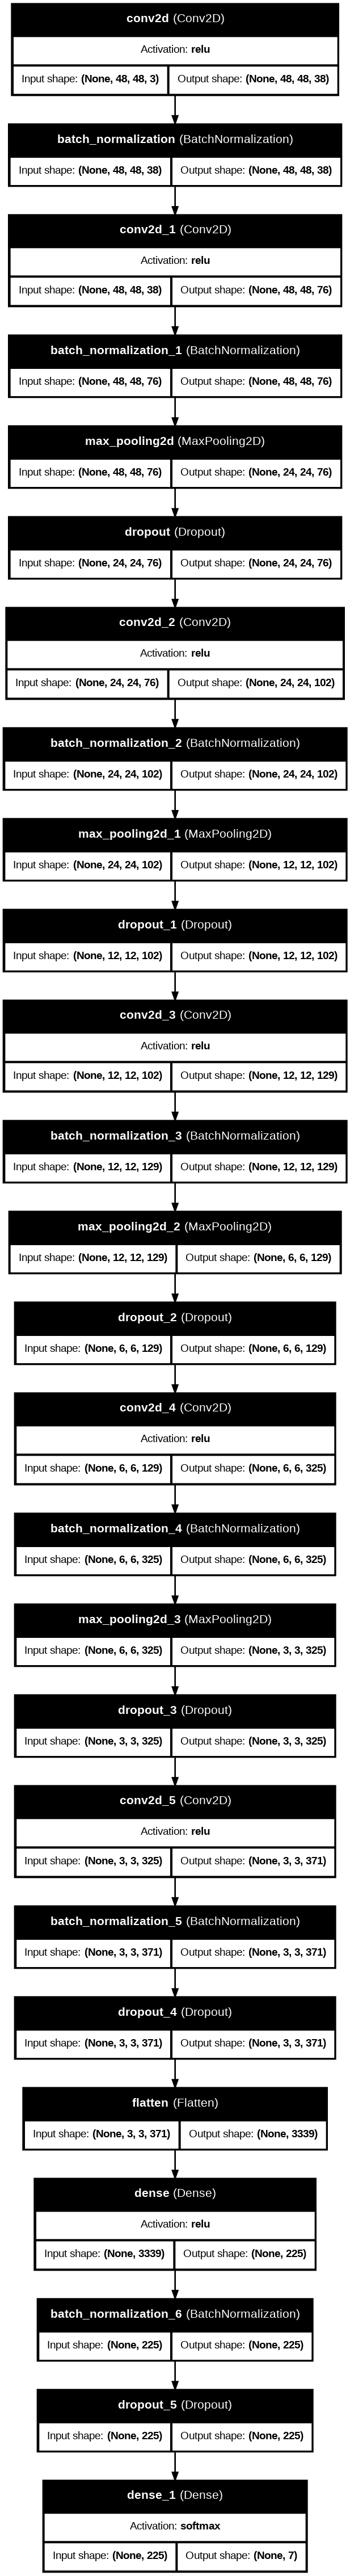

In [35]:
from tensorflow.keras.utils import plot_model

# Pastikan model sudah dibangun (misal: model = build_final_model())
plot_model(
    model,
    to_file='arsitektur_model_'+model_name+'.png', # Nama file yang akan disimpan
    show_shapes=True,                    # Menampilkan ukuran input/output (sangat membantu!)
    show_layer_names=True,               # Menampilkan nama layer
    show_layer_activations=True,         # Menampilkan fungsi aktivasi (ReLU, Softmax, dll)
    dpi=96                               # Kualitas gambar
)

In [36]:
# Pastikan callback ASK yang sudah diperbaiki atau checkpoint digunakan di sini
history = model.fit(
    train_generator,
    epochs=50, # Sesuaikan
    validation_data=validation_generator,
    callbacks=callbacks_list # Gunakan checkpoint agar model langsung tersimpan saat training
)

Epoch 1/50
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2077 - loss: 2.0252
Epoch 1: val_accuracy improved from -inf to 0.38929, saving model to best_modelCNN-PSO-5Layer-Filter-AlbAugmentation.keras
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.2078 - loss: 2.0251 - val_accuracy: 0.3893 - val_loss: 1.5713
Epoch 2/50
1261/1262 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4452 - loss: 1.4603
Epoch 2: val_accuracy improved from 0.38929 to 0.54514, saving model to best_modelCNN-PSO-5Layer-Filter-AlbAugmentation.keras
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.4452 - loss: 1.4602 - val_accuracy: 0.5451 - val_loss: 1.2597
Epoch 3/50
1261/1262 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5152 - loss: 1.2727
Epoch 3: val_accuracy improved from 0.54514 to 0.57044, saving model to best_modelCNN-PSO-5Layer-Filter-AlbAugmentation.keras
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.5153 - loss: 1.2727 - val_accuracy: 0.5704 - val_loss: 1.

# Evaluasi

In [37]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

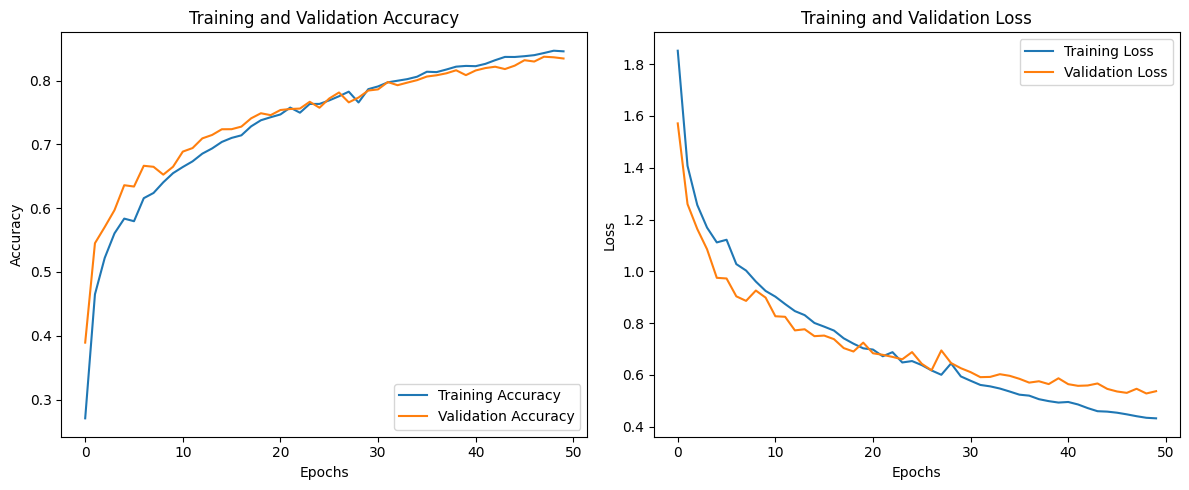

In [38]:
# Panggil fungsi ini setelah model.fit selesai
plot_training_history(history)

In [39]:
import numpy as np

def test_and_visualize_predictions(model, generator, classes):
    images, labels = next(generator)
    predictions = model.predict(images)
    
    plt.figure(figsize=(15, 15))
    
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        
        # --- PERBAIKAN VISUALISASI ---
        # Memastikan data dalam format yang benar untuk imshow
        img = images[i]
        if img.max() > 1.0:
            img = img / 255.0
        plt.imshow(img)
        # -----------------------------

        actual_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])
        confidence = predictions[i][pred_idx] * 100
        
        # Mengambil nama kelas (bukan index) untuk judul
        actual_name = classes[actual_idx]
        pred_name = classes[pred_idx]
        
        title = f"Actual: {actual_name}\nPred: {pred_name} ({confidence:.1f}%)"
        title_color = 'green' if actual_idx == pred_idx else 'red'
        
        plt.title(title, color=title_color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step


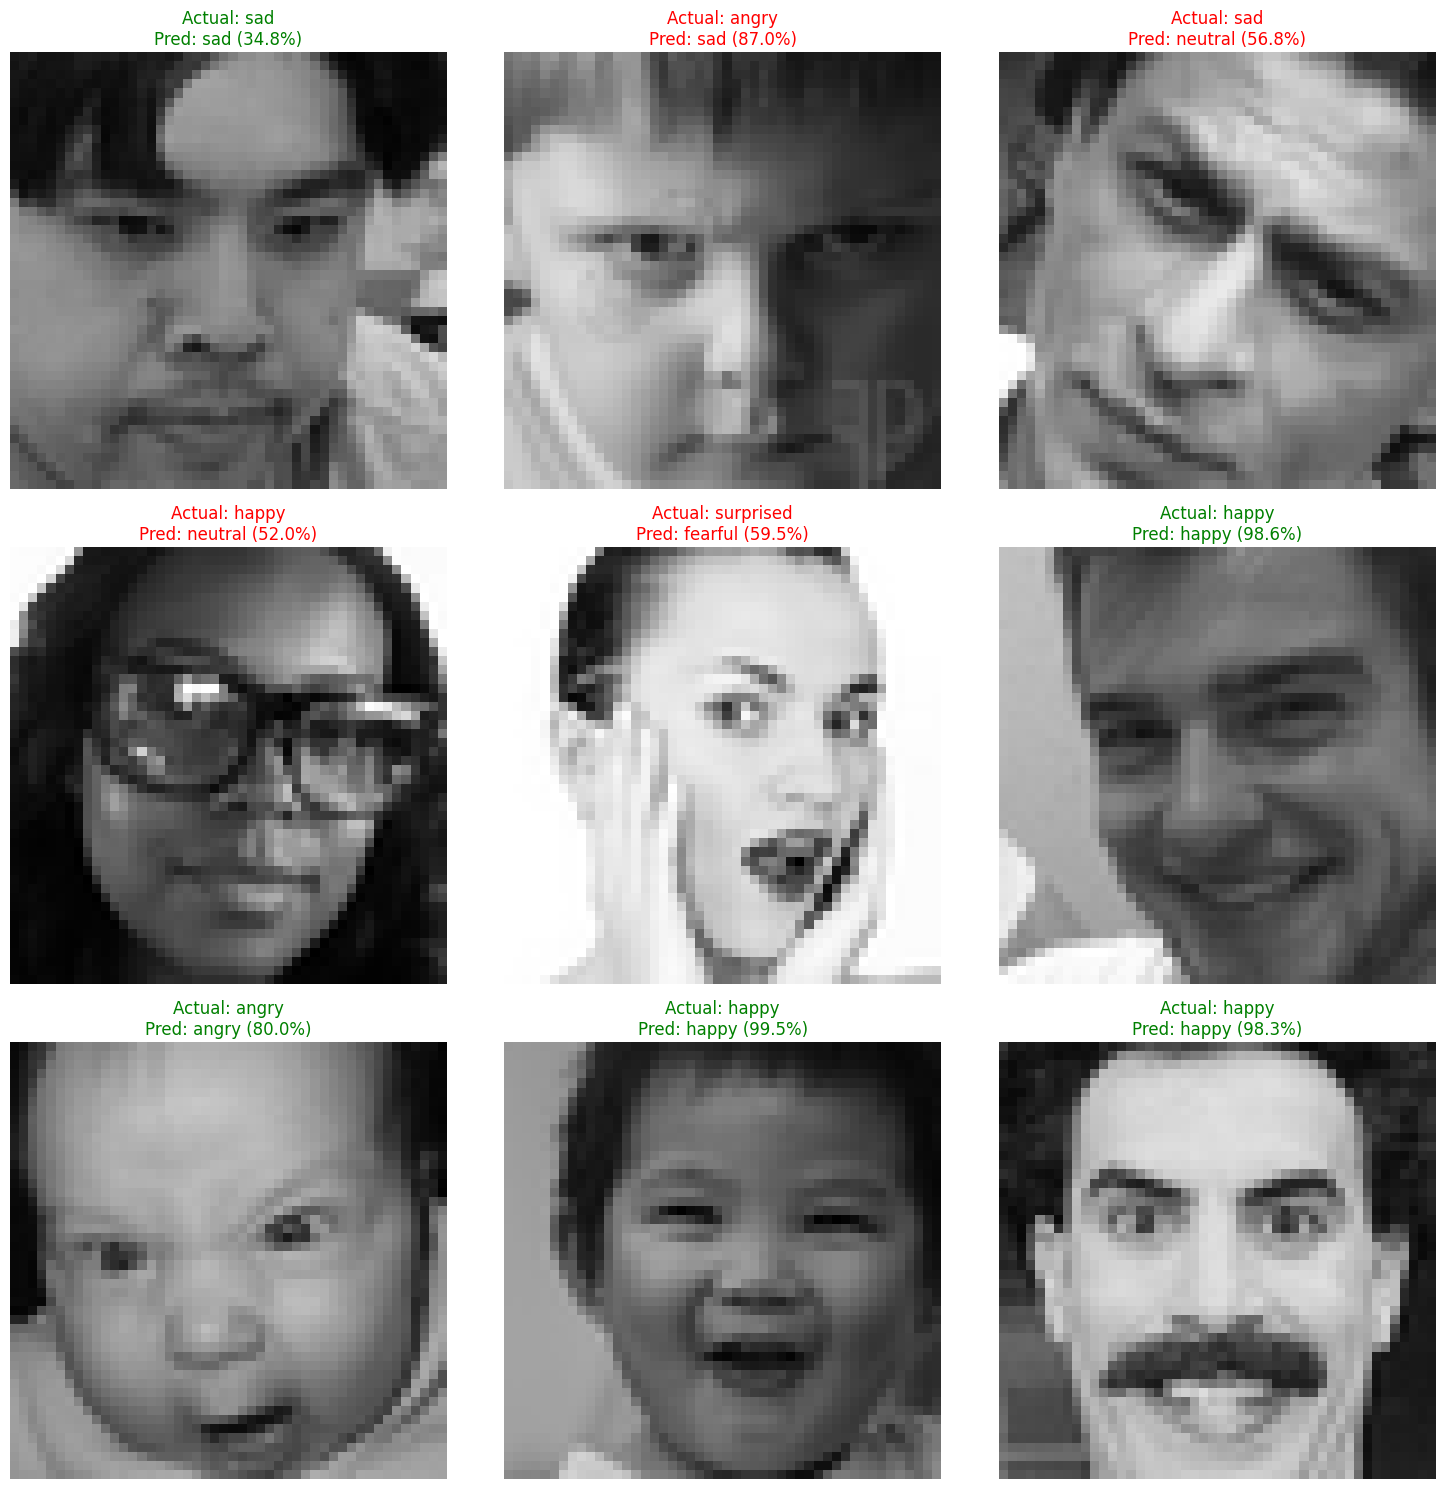

In [49]:
# Panggil fungsi ini untuk uji coba
test_and_visualize_predictions(model, test_generator_shuffled, classes)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def show_confusion_matrix(model, generator, classes):
    # Penting: Reset generator agar mulai dari awal
    generator.reset()
    
    # Ambil semua prediksi dari generator (shuffle harus False di sini)
    Y_pred = model.predict(generator)
    y_pred = np.argmax(Y_pred, axis=1)
    
    # Ambil label asli
    y_true = generator.classes
    
    # Hitung Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Print Classification Report
    print(classification_report(y_true, y_pred, target_names=classes))

In [51]:
# Gunakan test_generator (yang shuffle=False) untuk ini
show_confusion_matrix(model, test_generator_shuffled, classes)

AttributeError: 'AlbumentationsDataGenerator' object has no attribute 'reset'

In [43]:
# Langsung uji model yang sudah ada
results = model.evaluate(test_generator)
print("Hasil Evaluasi Data Test")
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 46s 259ms/step - accuracy: 0.6718 - loss: 1.1493
Hasil Evaluasi Data Test
Test Loss: 1.143293857574463, Test Accuracy: 0.6717877388000488


In [44]:
# Langsung uji model yang sudah ada
results_train = model.evaluate(train_generator)
print("Hasil Evaluasi Data Latih")
print(f"Train Loss: {results_train[0]}, Train Accuracy: {results_train[1]}")

1262/1262 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9004 - loss: 0.2886
Hasil Evaluasi Data Latih
Train Loss: 0.28823086619377136, Train Accuracy: 0.9002822637557983


In [45]:
# Langsung uji model yang sudah ada
results_val = model.evaluate(validation_generator)
print("Hasil Evaluasi Data Validasi")
print(f"Val Loss: {results_val[0]}, Val Accuracy: {results_val[1]}")

315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8354 - loss: 0.5432
Hasil Evaluasi Data Validasi
Val Loss: 0.5371772646903992, Val Accuracy: 0.8346230387687683


In [46]:
model.save(model_name+'.keras')

In [ ]:
model.save(model_name+'.h5')

In [50]:
# test_generator_shuffled = test_data_generator.flow_from_directory(
#                                         TEST_PATH, 
#                                         target_size=target_size,
#                                         class_mode='categorical', 
#                                         color_mode='rgb', 
#                                         classes=classes,
#                                         shuffle=True, 
#                                         batch_size=test_batch_size
#                                         )

test_generator_shuffled = AlbumentationsDataGenerator(
    directory=TEST_PATH,          # Folder data test kamu
    batch_size=32,
    shuffle=True,                # WAJIB False untuk pengujian/evaluasi
    transform=val_transform,       # Gunakan val_transform (Tanpa augmentasi rusak)
    classes=classes
)